# External Impulse Analytical Reference

This notebook implements the overdamped single-cell external impulse problem

We solve
$$
\mu \frac{dx}{dt} = F(t), \qquad v(t) = \frac{F(t)}{\mu}
$$
with
$$
F(t) = F_0\,\Theta(t-t_0)\,\Theta(t_0 + \Delta t - t).
$$

Requested outputs:
- velocity as a function of time
- travelled distance as a function of time

Default parameters match the image:
- cell diameter: `10 um`
- `t_0 = 3 s`
- `Delta t = 3 s`
- `t_max = 12 s`
- `dt = 0.1 s`
- output frequency: `0.2 s` (61 time points)
- `mu = 7.2 kg / min`
- `F_0 = 20 pN`
- initial velocity `v_0 = 0`


In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [33]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')


In [34]:
# Problem parameters
cell_diameter_um = 10.0
t0_s = 3.0
impulse_duration_s = 3.0
t_max_s = 12.0
solver_dt_s = 0.01
output_dt_s = 0.2
mu_kg_per_min = 7.2
F0_pN = 20.0
v0_m_per_s = 0.0

# Unit conversions
mu_kg_per_s = mu_kg_per_min / 60.0
F0_N = F0_pN * 1e-12

# Output times: 0, 0.2, ..., 12.0
time_s = np.arange(0.0, t_max_s + 0.5 * output_dt_s, output_dt_s)

mu_kg_per_s, F0_N, len(time_s)


(0.12000000000000001, 2e-11, 61)

## Analytical model

Because the dynamics are overdamped, the velocity is piecewise constant:
$$
v(t) = \frac{F_0}{\mu}\,\Theta(t-t_0)\,\Theta(t_0 + \Delta t - t).
$$

The travelled distance is the time integral of the velocity:
$$
d(t) = \int_0^t v(s)\,ds.
$$

This gives a piecewise expression:
$$
d(t) =
\begin{cases}
0, & t < t_0 \\
\frac{F_0}{\mu}(t-t_0), & t_0 \le t \le t_0 + \Delta t \\
\frac{F_0}{\mu}\Delta t, & t > t_0 + \Delta t
\end{cases}
$$
so the final displacement is `F0 / mu * Delta t`.


In [35]:
def heaviside(x: np.ndarray) -> np.ndarray:
    """Return the convention used in the problem statement: 1 for x >= 0 else 0."""
    return (x >= 0.0).astype(float)


def velocity_m_per_s(t_s: np.ndarray, force_N: float, friction_kg_per_s: float, start_s: float, duration_s: float) -> np.ndarray:
    return (force_N / friction_kg_per_s) * heaviside(t_s - start_s) * heaviside(start_s + duration_s - t_s)


def distance_m(t_s: np.ndarray, force_N: float, friction_kg_per_s: float, start_s: float, duration_s: float) -> np.ndarray:
    speed = force_N / friction_kg_per_s
    ramp = np.clip(t_s - start_s, 0.0, duration_s)
    return speed * ramp


In [36]:
velocity = velocity_m_per_s(time_s, F0_N, mu_kg_per_s, t0_s, impulse_duration_s)
distance = distance_m(time_s, F0_N, mu_kg_per_s, t0_s, impulse_duration_s)

results = pd.DataFrame(
    {
        'time_s': time_s,
        'velocity_m_per_s': velocity,
        'velocity_um_per_s': velocity * 1e6,
        'distance_m': distance,
        'distance_um': distance * 1e6,
    }
)

steady_velocity_um_per_s = (F0_N / mu_kg_per_s) * 1e6
final_distance_um = (F0_N / mu_kg_per_s) * impulse_duration_s * 1e6

print(f'Steady velocity: {steady_velocity_um_per_s:.6f} um/s')
print(f'Final travelled distance: {final_distance_um:.6f} um')
results.head(20)

Steady velocity: 0.000167 um/s
Final travelled distance: 0.000500 um


,time_s,velocity_m_per_s,velocity_um_per_s,distance_m,distance_um
0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000
1,0.2,0.000000e+00,0.000000,0.000000e+00,0.000000
2,0.4,0.000000e+00,0.000000,0.000000e+00,0.000000
3,0.6,0.000000e+00,0.000000,0.000000e+00,0.000000
4,0.8,0.000000e+00,0.000000,0.000000e+00,0.000000
5,1.0,0.000000e+00,0.000000,0.000000e+00,0.000000
6,1.2,0.000000e+00,0.000000,0.000000e+00,0.000000
7,1.4,0.000000e+00,0.000000,0.000000e+00,0.000000
8,1.6,0.000000e+00,0.000000,0.000000e+00,0.000000
9,1.8,0.000000e+00,0.000000,0.000000e+00,0.000000


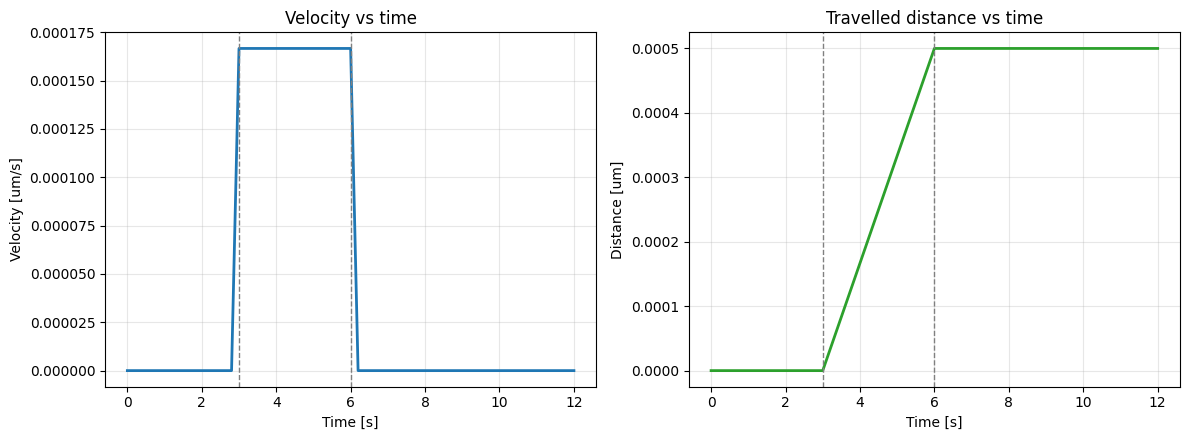

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(results['time_s'], results['velocity_um_per_s'], color='tab:blue', linewidth=2)
axes[0].axvline(t0_s, color='0.5', linestyle='--', linewidth=1)
axes[0].axvline(t0_s + impulse_duration_s, color='0.5', linestyle='--', linewidth=1)
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Velocity [um/s]')
axes[0].set_title('Velocity vs time')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results['time_s'], results['distance_um'], color='tab:green', linewidth=2)
axes[1].axvline(t0_s, color='0.5', linestyle='--', linewidth=1)
axes[1].axvline(t0_s + impulse_duration_s, color='0.5', linestyle='--', linewidth=1)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Distance [um]')
axes[1].set_title('Travelled distance vs time')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [38]:
output_path = Path('analytical_solutions/mechanics/analytical_values.csv')
results.to_csv(ROOT / output_path, index=False)
